# Example-08: Virtual phase

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

False


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example phase is estimated for virtual locations
# Virtual locations are locations where TbT data is not avalible, e.g. fault BPMs or other locations of interest
# Locations where TbT data is avalible, i.e. phase can be computed from TbT data, are denoted as monitors
# Using measured phase at monitors and model phase advance data, phase at a virtual location can be computed
# It is also possible to treat a monitor location as a virtual location
# In this case, phase estimation accuracy can be improved in some cases

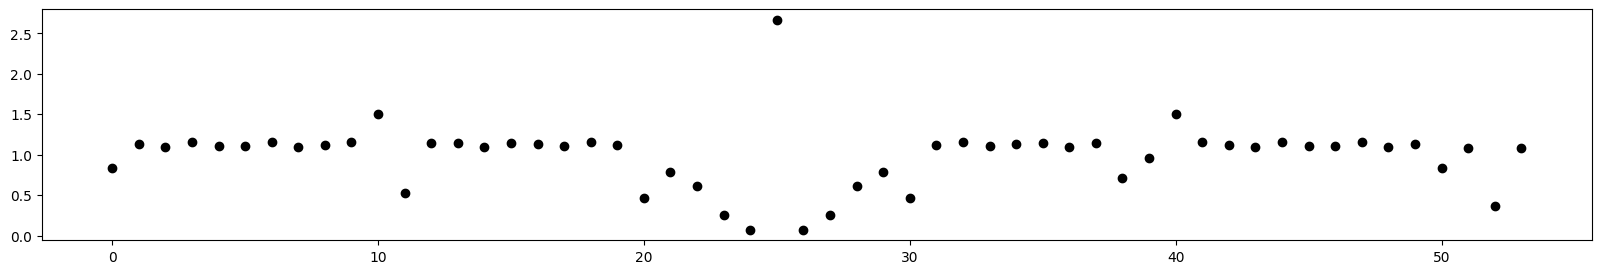

In [4]:
# Load model phase advance data
# Note, only monitor locations are selected, a subset of monitors will be demoted to virtual locations later
# Note, model phase advance error is given for each location (virtual or monitor), it corresponds to an error from given location to the next one

with open('../config.yaml', 'r') as stream:
    config = yaml.safe_load(stream)
    config = {key: config[key] for key in sorted(config.keys(), key=lambda name: config[name]['TIME'])}

total = config['TAIL']['FX']
model = torch.tensor([value['FX'] for key, value in config.items() if value['TYPE'] == 'MONITOR'], dtype=dtype, device=device)
error = 1.0E-4*torch.ones_like(model)

# Plot adjacent phase advance

model_advance, error_advance = Decomposition.phase_adjacent(total/(2.0*numpy.pi), model, error=True, sigma_frequency=None, sigma_phase=error, model=True)
plt.figure(figsize=(20, 3))
plt.errorbar(range(54), model_advance.cpu().numpy(), yerr=error_advance.cpu().numpy(), color='black', fmt=' ', marker='o')
plt.show()

In [5]:
# Estimate reference parameters

# Set window

length = 4096
w = Window(length, 'cosine_window', 5.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Estimate frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency

# Estimate amplitude for given frequency

h = Decomposition(d)
result, _ = h.harmonic_sum(frequency, w.window, d.data)
_, _, amplitude, phase = result.T

# Check maximum reconstruction error

result = []
for a, b in zip(amplitude, phase):
    result.append(Data.make_harmonic(length, frequency, a=a, b=b, dtype=dtype, device=device))
result = torch.stack(result)
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}, error={(d.data - result).abs().max().item():12.9}')

frequency= 0.536883099, spread=1.3554573e-16, error=2.56151871e-13


In [6]:
# Real TbT data length is limited by decoherence
# In this example 1024 turns are used for frequency estimation and only 512 for phase

# Set window

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Add random noise

n = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))
d.add_noise(n)
d.data.copy_(d.work)

# Estimate frequency (average over signals)

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}')

frequency= 0.536883067, spread=1.21409518e-06


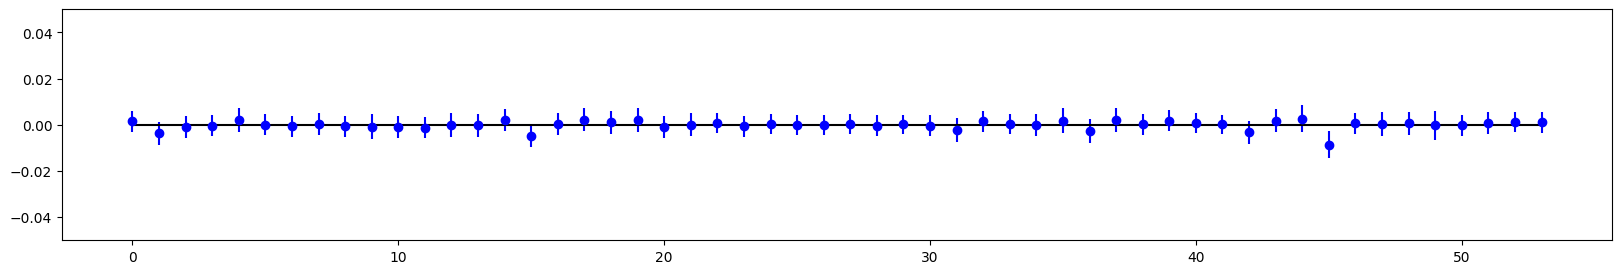

tensor(6.659739833726e-02, dtype=torch.float64)


In [7]:
# Estimate phase

dec = Decomposition(d)
phase_estimate, error_estimate, _ = dec.harmonic_phase(frequency, length=256, order=0.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, method='noise')

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (phase_estimate - phase).cpu().numpy(), yerr=error_estimate.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

print((phase_estimate - phase).abs().sum())

location=5
monitor: [error, sigma] = [5.4700081829561764e-05, 0.004556258429627504]
virtual: [error, sigma] = [9.537405693221812e-05, 0.001623425058489849]
location=25
monitor: [error, sigma] = [0.00029040661077056606, 0.004322526040924583]
virtual: [error, sigma] = [5.106648875791153e-05, 0.0014569386271134107]


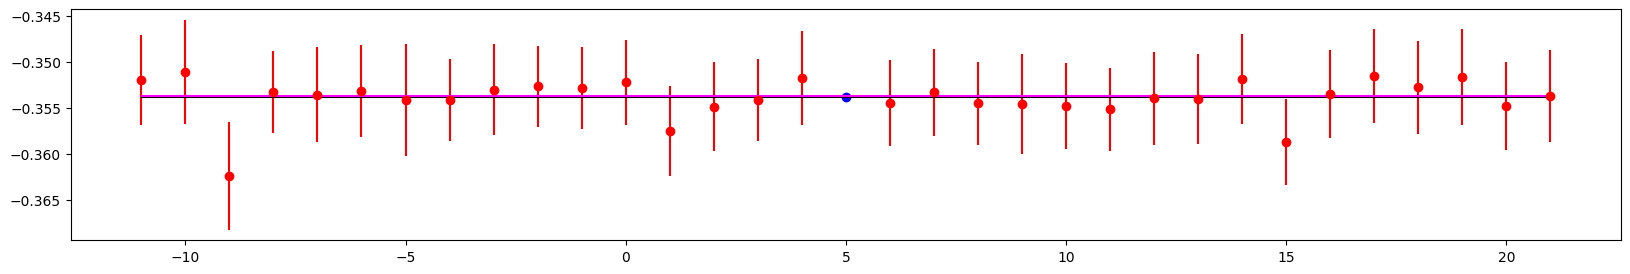

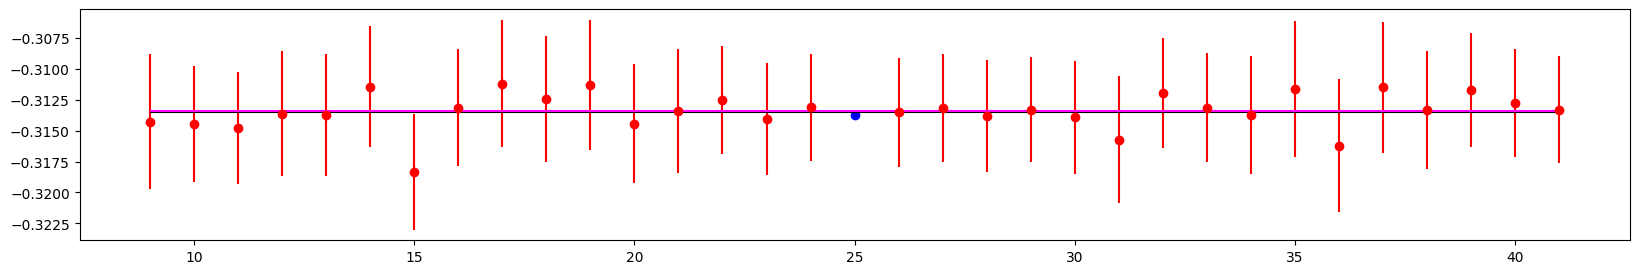

In [8]:
# Virtual phase

# Set demoted location
# Note, location index starts from zero

index = [5, 25]

# Set location flags, 0/1 for virtual/monitor locations

flags = torch.ones_like(model, dtype=torch.int64, device=device)
flags[index] = 0

# Set measured & model frequency with errors

q, sigma_q = frequency, spread
Q, sigma_Q = total/(2.0*numpy.pi), torch.sqrt(torch.sum(error**2))/(2.0*numpy.pi)

# Set measured phase with errors

phase_measured = torch.clone(phase_estimate)
error_measured = torch.clone(error_estimate)
phase_measured[index] = 0.0
error_measured[index] = 0.0

# Set model phase with error

phase_model = torch.clone(model)
error_model = torch.clone(error)

# Set range limit

limit = 16

# Estimate virtial phase for each virtual location

for location in index:
    
    result = dec.phase_virtual(location, limit, flags, q, Q, phase_measured, phase_model,
                               sigma_frequency=sigma_q, sigma_frequency_model=sigma_Q, 
                               sigma_phase=error_measured, sigma_phase_model=error_model,
                               full=True, clean=True)
    
    # Compare fit result with model
    
    print(f'{location=}')
    print(f'monitor: [error, sigma] = {[abs(phase[location] - phase_estimate[location]).item(), error_estimate[location].item()]}')
    print(f'virtual: [error, sigma] = {[abs(phase[location] - result["model"][0]).item(), result["model"][1].item()]}')
    
    #  Plot data for all locations
    
    plt.figure(figsize=(20, 3))
    plt.errorbar(list(result['index']), result['phase'].cpu().numpy(), yerr=result['error'].cpu().numpy(), color='red', fmt=' ', marker='o')
    plt.scatter(location, phase_estimate[location].cpu().numpy(), color='blue')
    plt.hlines(phase[location].cpu().numpy(), min(result['index'].keys()), max(result['index'].keys()), color='black')
    plt.hlines(result['model'][0].cpu().numpy(), min(result['index'].keys()), max(result['index'].keys()), color='magenta')

plt.show()
    
# red     -- estimation using different monitors 
# blue    -- estimation from TbT
# black   -- reference value
# magenta -- fitted value

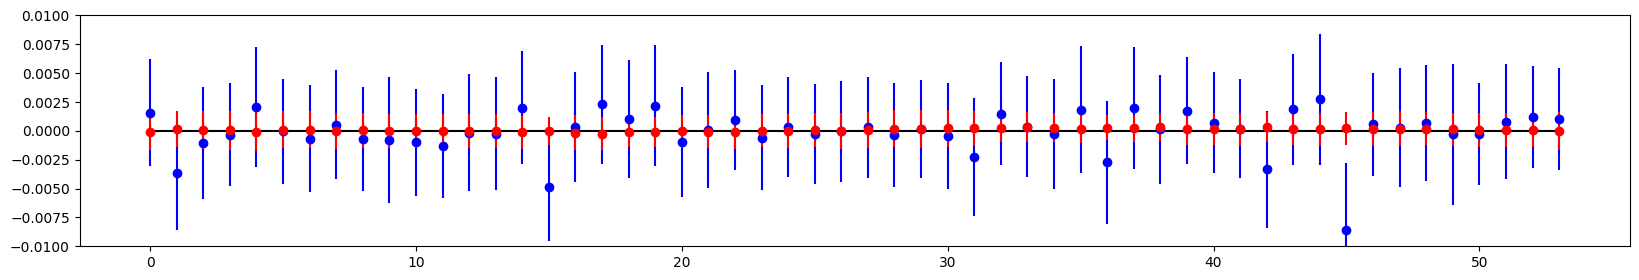

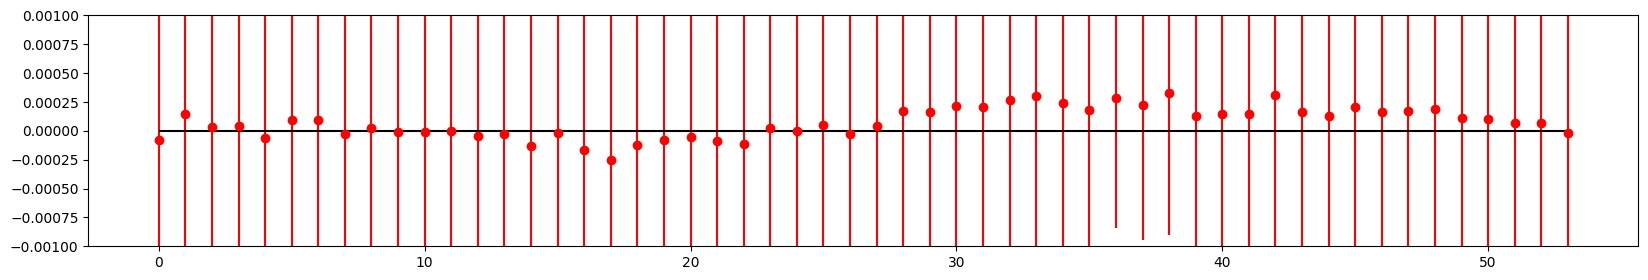

tensor(6.659739833726e-02, dtype=torch.float64)
tensor(6.598806774028e-03, dtype=torch.float64)


In [9]:
# Virtual phase for monitors

# Note, change limit value

# Set location flags, 0/1 for virtual/monitor locations

flags = torch.ones_like(model, dtype=torch.int32)

# Set measured & model frequency with errors

q, sigma_q = frequency, spread
Q, sigma_Q = total/(2.0*numpy.pi), torch.sqrt(torch.sum(error**2))/(2.0*numpy.pi)

# Set measured phase with errors

phase_measured = torch.clone(phase_estimate)
error_measured = torch.clone(error_estimate)

# Set model phase with error

phase_model = torch.clone(model)
error_model = torch.clone(error)

# Set range limit

limit = 16

# Estimate virtial phase for each virtual location

out = []
for location in range(len(flags)):
    
    result = dec.phase_virtual(location, limit, flags, q, Q, phase_measured, phase_model, 
                               sigma_frequency=sigma_q, sigma_frequency_model=sigma_Q, 
                               sigma_phase=error_measured, sigma_phase_model=error_model,
                               full=True, clean=True)
    
    out.append(result['model'])
    
phase_virtual, error_virtual = torch.stack(out).T

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (phase_estimate - phase).cpu().numpy(), yerr=error_estimate.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.errorbar(range(54), (phase_virtual - phase).cpu().numpy(), yerr=error_virtual.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-1.0E-2, +1.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (phase_virtual - phase).cpu().numpy(), yerr=error_virtual.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-1.0E-3, +1.0E-3)
plt.show()

print((phase_estimate - phase).abs().sum())
print((phase_virtual - phase).abs().sum())

# Note, such 'correction' introduces bias, use with error estimates with care, adjust limit

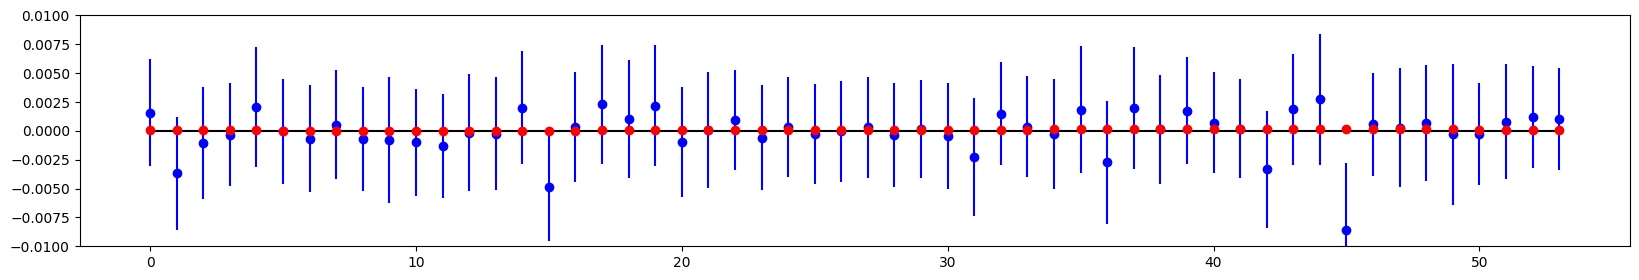

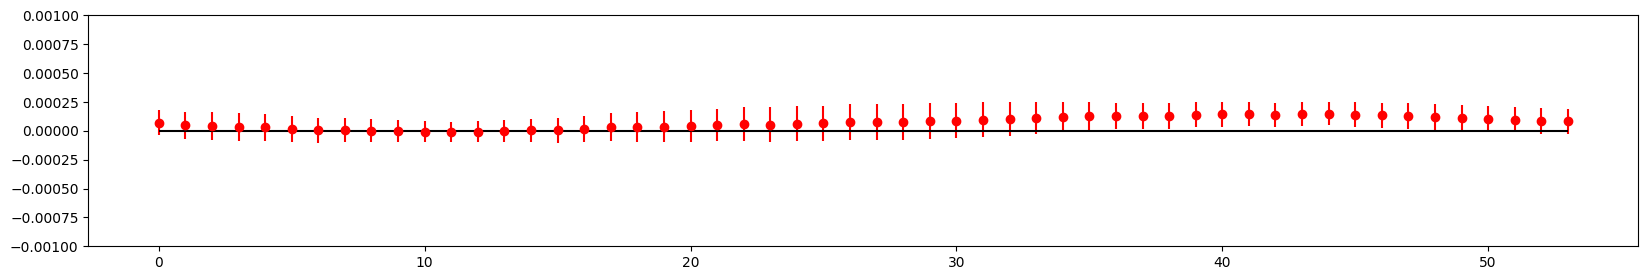

tensor(6.659739833726e-02, dtype=torch.float64)
tensor(3.933224894171e-03, dtype=torch.float64)


In [10]:
# Virtual phase for monitors (second pass)

# Note, second pass (or more) impoves std in general
# Note, change limit value

# Set location flags, 0/1 for virtual/monitor locations

flags = torch.ones_like(model, dtype=torch.int32)

# Set measured & model frequency with errors

q, sigma_q = frequency, spread
Q, sigma_Q = total/(2.0*numpy.pi), torch.sqrt(torch.sum(error**2))/(2.0*numpy.pi)

# Set measured phase with errors

phase_measured = torch.clone(phase_virtual)
error_measured = torch.clone(error_estimate)

# Set model phase with error

phase_model = torch.clone(model)
error_model = torch.clone(error)

# Set range limit

limit = limit

# Estimate virtial phase for each virtual location

out = []
for location in range(len(flags)):
    
    result = dec.phase_virtual(location, limit, flags, q, Q, phase_measured, phase_model, 
                               sigma_frequency=sigma_q, sigma_frequency_model=sigma_Q, 
                               sigma_phase=error_measured, sigma_phase_model=error_model,
                               full=True, clean=True)
    
    out.append(result['model'])
    
phase_virtual, error_virtual = torch.stack(out).T

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (phase_estimate - phase).cpu().numpy(), yerr=error_estimate.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.errorbar(range(54), (phase_virtual - phase).cpu().numpy(), yerr=error_virtual.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-1.0E-2, +1.0E-2)
plt.show()

# Note, such 'correction' introduces bias, use with care, adjust limit

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (phase_virtual - phase).cpu().numpy(), yerr=error_virtual.cpu().numpy(), fmt=' ', marker='o', color='red')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-1.0E-3, +1.0E-3)
plt.show()

print((phase_estimate - phase).abs().sum())
print((phase_virtual - phase).abs().sum())